In [5]:
import pandas as pd
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [2]:
def predict_proba(X, w):
    if isinstance(X, pd.DataFrame) or isinstance(X, pd.Series):
        X_val = X.values
    else:
        X_val = X
    return sigmoid(X_val.dot(w))

In [3]:
def predict_class(X, w, threshold=0.5):
    return (predict_proba(X, w) >= threshold).astype(int)

In [6]:
def compute_logistic_cost(X, y, w):
    m = len(y)
    h = predict_proba(X, w)

    if isinstance(y, pd.Series):
        y_val = y.values.reshape(-1, 1)
    else:
        y_val = y

    epsilon = 1e-8  # to avoid log(0)
    cost = -(1/m) * np.sum(
        y_val * np.log(h + epsilon) +
        (1 - y_val) * np.log(1 - h + epsilon)
    )
    return cost

In [7]:
def mini_batch_gradient_descent_logistic(X, y, w, alpha, epochs, batch_size):
    m = len(y)
    cost_history = []

    for epoch in range(epochs):
        for i in range(0, m, batch_size):
            X_batch = X[i: i + batch_size]
            y_batch = y[i: i + batch_size]

            h = predict_proba(X_batch, w)

            gradient = (1 / len(y_batch)) * \
                X_batch.values.T.dot(h - y_batch.values.reshape(-1, 1))

            w = w - alpha * gradient

        cost_history.append(compute_logistic_cost(X, y, w))

    return w, cost_history

In [34]:
dataset = pd.read_csv("/content/Heart Attack.csv")
dataset = dataset[['impluse', 'pressurehight', 'pressurelow', 'glucose', 'kcm', 'troponin', 'class']]
dataset['class'] = dataset['class'].map({'positive': 1, 'negative': 0})


train = dataset.sample(frac=0.8, random_state=0)
test = dataset.drop(train.index) # remaining 20%

X_ori = train.iloc[:, :-1] # DataFrame of original 8 features
X_ori_mean = X_ori.mean(axis=0)
X_ori_std  = X_ori.std(axis=0)
X_norm = (X_ori - X_ori_mean) / X_ori_std
y_target = train.iloc[:, -1]    # Series of target values

# Add a bias (intercept) term to X_features_original
# Create a DataFrame for the bias term (a column of ones)
bias_column = pd.DataFrame(np.ones((X_norm.shape[0], 1)),
                           index=X_norm.index,
                           columns=['bias'])

X = pd.concat([bias_column, X_norm], axis=1)
# Assign y for gradient descent
y = y_target

In [52]:
num_features = X.shape[1]
w_init = np.zeros((num_features, 1))

alpha = 0.01
epochs = 500
batch_size = 16

w_final, cost_history = mini_batch_gradient_descent_logistic(
    X, y, w_init, alpha, epochs, batch_size
)

print("Final cost:", cost_history[-1])

Final cost: 0.4907866032649699


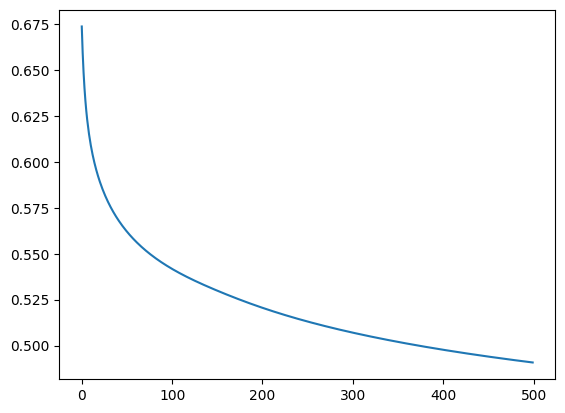

In [53]:
import matplotlib.pyplot as plt
plt.plot(cost_history)

In [54]:
X_test_ori = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

# Normalize test features using TRAIN mean & std
X_test_norm = (X_test_ori - X_ori_mean) / X_ori_std

# Add bias column
bias_test = pd.DataFrame(np.ones((X_test_norm.shape[0], 1)),
                         index=X_test_norm.index,
                         columns=['bias'])

X_test = pd.concat([bias_test, X_test_norm], axis=1)

y_pred_prob = predict_proba(X_test, w_final)
y_pred_class = (y_pred_prob >= 0.5).astype(int)

accuracy = np.mean(y_pred_class.flatten() == y_test.values)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.821969696969697
